In [17]:
!pip install -q sentence-transformers xgboost lightgbm catboost



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [18]:
import random
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.base import clone

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Optional boosting libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

print("Libraries loaded. Random state:", RANDOM_STATE)


Libraries loaded. Random state: 42


## 1. Data Loading and Preparation


In [19]:
DATA_PATH = "/workspaces/pcf-quality-framework/BEACON-PCF/data/PublicTablesForCarbonCatalogueDataDescriptor_v30Oct2021(Product Level Data).csv"
df = pd.read_csv(DATA_PATH, encoding="latin1")
print("Dataset shape:", df.shape)

Dataset shape: (866, 25)


In [20]:
TARGET = "Product's carbon footprint (PCF, kg CO2e)"

TEXT_FEATURES = [
    "Product name (and functional unit)",
    "Company",
    "Country (where company is incorporated)"
]

NUMERIC_FEATURES = [
    "Year of reporting",
    "Product weight (kg)"
]

CATEGORICAL_FEATURES = [
    "Company's GICS Industry",
    "Protocol used for PCF",
    "*Stage-level CO2e available"
]

STRUCTURED_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
REQUIRED_COLUMNS = [TARGET] + TEXT_FEATURES + STRUCTURED_FEATURES

missing_columns = [c for c in REQUIRED_COLUMNS if c not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

data = df[REQUIRED_COLUMNS].copy()

data[TARGET] = pd.to_numeric(data[TARGET], errors="coerce")
for col in NUMERIC_FEATURES:
    data[col] = pd.to_numeric(data[col], errors="coerce")

for col in TEXT_FEATURES:
    data[col] = (
        data[col].fillna("").astype(str).str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

for col in CATEGORICAL_FEATURES:
    data[col] = data[col].fillna("Missing").astype(str).str.strip()

data = data.dropna(subset=[TARGET]).reset_index(drop=True)

print("Final working dataset:", data.shape)


Final working dataset: (866, 9)


In [21]:
data["Combined_Text"] = (
    "Product: " + data["Product name (and functional unit)"]
    + " | Company: " + data["Company"]
    + " | Country: " + data["Country (where company is incorporated)"]
)

train_df, test_df = train_test_split(
    data,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Development observations:", len(train_df))
print("Independent test observations:", len(test_df))


Development observations: 692
Independent test observations: 174


## 2. Target and Numerical Pre-processing


In [22]:
y = train_df[TARGET]

print("Median PCF:", y.median(), "kg CO2e")
print("75th percentile:", y.quantile(0.75), "kg CO2e")
print("Maximum PCF:", y.max(), "kg CO2e")
print("Raw skewness:", y.skew())

y_log = np.log1p(y)

print("log1p skewness:", y_log.skew())


Median PCF: 110.4 kg CO2e
75th percentile: 1600.0 kg CO2e
Maximum PCF: 3718044.0 kg CO2e
Raw skewness: 15.771399172833995
log1p skewness: 0.22285224862565456


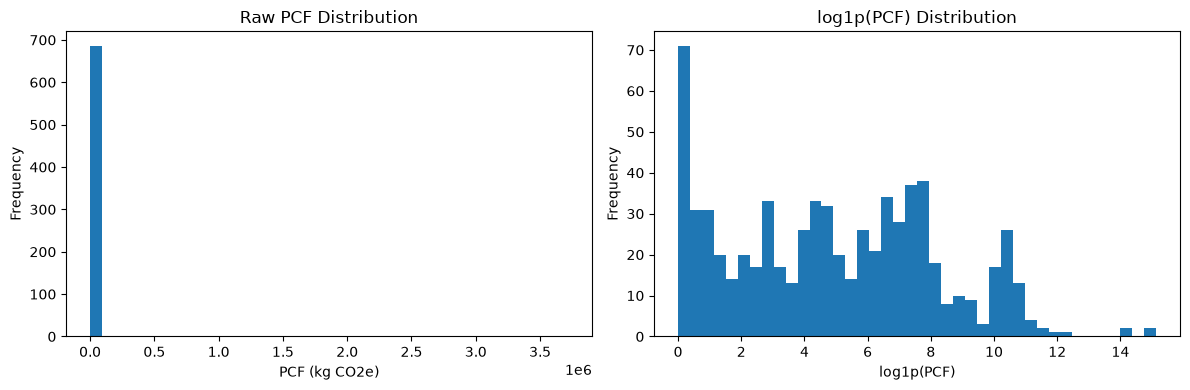

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=40)
axes[0].set_title("Raw PCF Distribution")
axes[0].set_xlabel("PCF (kg CO2e)")
axes[0].set_ylabel("Frequency")

axes[1].hist(y_log, bins=40)
axes[1].set_title("log1p(PCF) Distribution")
axes[1].set_xlabel("log1p(PCF)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [24]:
WEIGHT_COL = "Product weight (kg)"
YEAR_COL = "Year of reporting"
OTHER_CATEGORICAL_FEATURES = [
    "Company's GICS Industry",
    "Protocol used for PCF",
    "*Stage-level CO2e available"
]

weight_train = pd.to_numeric(train_df[WEIGHT_COL], errors="coerce")

LOWER_Q = 0.01
UPPER_Q = 0.99

weight_lower = weight_train.quantile(LOWER_Q)
weight_upper = weight_train.quantile(UPPER_Q)

weight_winsorized = weight_train.clip(
    lower=weight_lower,
    upper=weight_upper
)

print("Product Weight maximum:", weight_train.max(), "kg")
print("Training-derived lower limit:", weight_lower)
print("Training-derived upper limit:", weight_upper)


Product Weight maximum: 600000.0 kg
Training-derived lower limit: 0.0085
Training-derived upper limit: 3500.0


In [25]:
# plt.figure(figsize=(8, 5))
# plt.boxplot(
#     [weight_train.dropna(), weight_winsorized.dropna()],
#     labels=["Before", "After Winsorisation"],
#     showfliers=True
# )
# plt.ylabel("Product Weight (kg)")
# plt.title("Product Weight Before and After Winsorisation")
# plt.tight_layout()
# plt.show()


## 3. Leakage-Safe Feature Engineering Functions


In [26]:
# ============================================================
# 18. LEAKAGE-SAFE WINSORIZATION
# ============================================================

def fit_winsorization(
    X,
    column,
    lower_quantile=0.01,
    upper_quantile=0.99
):
    """
    Calculate Winsorization limits using
    training data only.
    """

    lower_limit = X[column].quantile(
        lower_quantile
    )

    upper_limit = X[column].quantile(
        upper_quantile
    )

    return lower_limit, upper_limit


def apply_winsorization(
    X,
    column,
    lower_limit,
    upper_limit
):
    """
    Apply previously learned Winsorization
    limits to any dataset.
    """

    X = X.copy()

    X[column] = X[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

    return X

In [27]:
# ============================================================
# 20.2 COUNTRY TARGET ENCODING
# ============================================================

def fit_country_target_encoding(
    country_series,
    y
):
    """
    Learn Country -> mean target mapping
    using training data only.
    """

    temp = pd.DataFrame({
        "Country": country_series,
        "Target": np.asarray(y)
    })

    global_mean = temp["Target"].mean()

    country_means = (
        temp.groupby("Country")["Target"]
        .mean()
        .to_dict()
    )

    return country_means, global_mean


def apply_country_target_encoding(
    country_series,
    country_means,
    global_mean
):
    """
    Apply a previously learned Country -> target mapping.

    Unknown countries use the training-fold global mean.
    """

    encoded = (
        country_series
        .map(country_means)
        .fillna(global_mean)
        .astype(float)
        .to_numpy()
    )

    return encoded

In [28]:
# ============================================================
# 37.1 LEAKAGE-SAFE OOF COUNTRY TARGET ENCODING
# ============================================================

from sklearn.model_selection import KFold


def fit_country_target_encoding_oof(
    country_series,
    y,
    n_splits=5,
    random_state=42
):
    """
    Create out-of-fold target encoding for training data.

    Each training row receives a country mean calculated
    without using that row's own target.

    Returns
    -------
    oof_encoded : np.ndarray
        Leakage-safe encoding for training rows.

    country_means : pd.Series
        Country means learned from the FULL training data.
        Used later for outer validation/test data.

    global_mean : float
        Global training-target mean.
    """

    country_series = pd.Series(
        country_series
    ).reset_index(drop=True)

    y = np.asarray(y)

    oof_encoded = np.zeros(
        len(country_series),
        dtype=float
    )

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    for inner_train_idx, inner_valid_idx in kf.split(
        country_series
    ):

        inner_country_train = (
            country_series.iloc[inner_train_idx]
        )

        inner_y_train = (
            y[inner_train_idx]
        )

        # Learn encoding ONLY from inner-training data
        temp_df = pd.DataFrame({
            "Country": inner_country_train.values,
            "Target": inner_y_train
        })

        country_means_inner = (
            temp_df
            .groupby("Country")["Target"]
            .mean()
        )

        global_mean_inner = (
            temp_df["Target"].mean()
        )

        # Apply to inner-validation rows
        inner_valid_countries = (
            country_series.iloc[inner_valid_idx]
        )

        encoded_valid = (
            inner_valid_countries
            .map(country_means_inner)
            .fillna(global_mean_inner)
            .to_numpy()
        )

        oof_encoded[inner_valid_idx] = (
            encoded_valid
        )

    # --------------------------------------------------------
    # Full outer-training mapping
    # Used ONLY for outer validation/test data
    # --------------------------------------------------------

    full_train_df = pd.DataFrame({
        "Country": country_series.values,
        "Target": y
    })

    country_means = (
        full_train_df
        .groupby("Country")["Target"]
        .mean()
    )

    global_mean = (
        full_train_df["Target"].mean()
    )

    return (
        oof_encoded,
        country_means,
        global_mean
    )


def apply_country_target_encoding(
    country_series,
    country_means,
    global_mean
):
    """
    Apply a target-encoding mapping learned from
    training data only.
    """

    return (
        pd.Series(country_series)
        .map(country_means)
        .fillna(global_mean)
        .to_numpy()
    )

In [29]:
# ============================================================
# 37.3 UPDATED LEAKAGE-SAFE STRUCTURED FEATURE BUILDER
# ============================================================

def build_structured_features(
    X_train,
    y_train,
    X_valid,
    country_encoding="ohe"
):
    """
    Build structured features using training-fold information only.

    Country options:
        "ohe"
        "target"
        "target_oof"

    target_oof:
        Training rows receive out-of-fold target encoding.
        Validation rows receive encoding learned from the
        complete outer training fold.
    """

    # --------------------------------------------------------
    # 1. COPY DATA
    # --------------------------------------------------------

    train_part = X_train.copy()
    valid_part = X_valid.copy()


    # --------------------------------------------------------
    # 2. WINSORIZE PRODUCT WEIGHT
    #    Learn limits from training fold ONLY
    # --------------------------------------------------------

    lower_limit, upper_limit = fit_winsorization(
        train_part,
        WEIGHT_COL,
        lower_quantile=0.01,
        upper_quantile=0.99
    )

    train_part = apply_winsorization(
        train_part,
        WEIGHT_COL,
        lower_limit,
        upper_limit
    )

    valid_part = apply_winsorization(
        valid_part,
        WEIGHT_COL,
        lower_limit,
        upper_limit
    )


    # --------------------------------------------------------
    # 3. NUMERICAL FEATURES
    # --------------------------------------------------------

    train_numeric = train_part[
        [YEAR_COL, WEIGHT_COL]
    ].apply(
        pd.to_numeric,
        errors="coerce"
    )

    valid_numeric = valid_part[
        [YEAR_COL, WEIGHT_COL]
    ].apply(
        pd.to_numeric,
        errors="coerce"
    )


    # --------------------------------------------------------
    # 4. OTHER CATEGORICAL FEATURES → OHE
    # --------------------------------------------------------

    other_ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

    train_other_ohe = other_ohe.fit_transform(
        train_part[OTHER_CATEGORICAL_FEATURES]
    )

    valid_other_ohe = other_ohe.transform(
        valid_part[OTHER_CATEGORICAL_FEATURES]
    )


    # --------------------------------------------------------
    # 5. COUNTRY
    # --------------------------------------------------------

    if country_encoding == "ohe":

        country_ohe = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )

        train_country = country_ohe.fit_transform(
            train_part[[COUNTRY_COL]]
        )

        valid_country = country_ohe.transform(
            valid_part[[COUNTRY_COL]]
        )


    elif country_encoding == "target":

        country_means, global_mean = (
            fit_country_target_encoding(
                train_part[COUNTRY_COL],
                y_train
            )
        )

        train_country = (
            apply_country_target_encoding(
                train_part[COUNTRY_COL],
                country_means,
                global_mean
            ).reshape(-1, 1)
        )

        valid_country = (
            apply_country_target_encoding(
                valid_part[COUNTRY_COL],
                country_means,
                global_mean
            ).reshape(-1, 1)
        )


    elif country_encoding == "target_oof":

        # ----------------------------------------------------
        # OOF encoding for OUTER TRAINING data
        # ----------------------------------------------------

        (
            train_country_oof,
            country_means,
            global_mean
        ) = fit_country_target_encoding_oof(
            train_part[COUNTRY_COL].reset_index(
                drop=True
            ),
            y_train,
            n_splits=5,
            random_state=42
        )

        train_country = (
            train_country_oof.reshape(-1, 1)
        )

        # ----------------------------------------------------
        # Validation uses mapping learned from FULL
        # outer training data
        # ----------------------------------------------------

        valid_country = (
            apply_country_target_encoding(
                valid_part[COUNTRY_COL],
                country_means,
                global_mean
            ).reshape(-1, 1)
        )


    else:

        raise ValueError(
            "country_encoding must be "
            "'ohe', 'target', or 'target_oof'"
        )


    # --------------------------------------------------------
    # 6. COMBINE STRUCTURED FEATURES
    # --------------------------------------------------------

    X_train_structured = np.hstack([
        train_numeric.to_numpy(),
        train_other_ohe,
        train_country
    ])

    X_valid_structured = np.hstack([
        valid_numeric.to_numpy(),
        valid_other_ohe,
        valid_country
    ])


    return (
        X_train_structured,
        X_valid_structured
    )

In [30]:
# ============================================================
# 22.2 LEAKAGE-SAFE PCA FUNCTION
# ============================================================

def apply_pca_to_sbert(
    X_train_sbert_fold,
    X_valid_sbert_fold,
    n_components
):
    """
    Fit PCA on the training-fold SBERT embeddings only,
    then transform both training and validation embeddings.
    """

    pca = PCA(
        n_components=n_components,
        random_state=42
    )

    # Fit ONLY on training fold
    X_train_pca = pca.fit_transform(
        X_train_sbert_fold
    )

    # Transform validation using the same fitted PCA
    X_valid_pca = pca.transform(
        X_valid_sbert_fold
    )

    return (
        X_train_pca,
        X_valid_pca,
        pca
    )

In [31]:
# ============================================================
# 23. HYBRID FEATURE FUSION
# ============================================================

def fuse_features(
    sbert_features,
    structured_features
):
    """
    Concatenate SBERT/text features with
    structured features horizontally.
    """

    return np.hstack([
        sbert_features,
        structured_features
    ])

## 4. Semantic Representation with Sentence-BERT


In [32]:
from sentence_transformers import SentenceTransformer

SBERT_MODEL_NAME = "all-MiniLM-L6-v2"
sbert_model = SentenceTransformer(SBERT_MODEL_NAME)

train_texts = train_df["Combined_Text"].fillna("").astype(str).tolist()
test_texts = test_df["Combined_Text"].fillna("").astype(str).tolist()

X_train_sbert = sbert_model.encode(
    train_texts,
    show_progress_bar=True,
    convert_to_numpy=True
)

X_test_sbert = sbert_model.encode(
    test_texts,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("SBERT dimension:", X_train_sbert.shape[1])
print("Training embeddings:", X_train_sbert.shape)
print("Test embeddings:", X_test_sbert.shape)


Batches: 100%|██████████| 6/6 [00:02<00:00,  2.77it/s]

SBERT dimension: 384
Training embeddings: (692, 384)
Test embeddings: (174, 384)


## 5. Five-Fold Development Evaluation


In [33]:
from sklearn.model_selection import StratifiedKFold

target_bins = pd.qcut(
    y_log,
    q=5,
    labels=False,
    duplicates="drop"
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Stratified folds:", skf.n_splits)


Stratified folds: 5


### 5.1 PCA Component Selection


In [34]:

COUNTRY_COL = "Country (where company is incorporated)"

In [35]:
# ============================================================
# 33. PCA EXPERIMENT
#     Log Target + Country OHE + Random Forest
#     Stratified 5-Fold CV
# ============================================================

PCA_COMPONENTS = [50, 100, 150, 200]

pca_results = []

for n_components in PCA_COMPONENTS:

    print("\n" + "#" * 70)
    print(f"PCA COMPONENTS = {n_components}")
    print("#" * 70)

    fold_results = []

    for fold, (train_idx, valid_idx) in enumerate(
        skf.split(train_df, target_bins),
        start=1
    ):

        print(f"\n{'='*60}")
        print(f"PCA {n_components} — FOLD {fold}")
        print(f"{'='*60}")

        # ----------------------------------------------------
        # 1. Split dataframe
        # ----------------------------------------------------

        X_fold_train = train_df.iloc[train_idx].copy()
        X_fold_valid = train_df.iloc[valid_idx].copy()

        # ----------------------------------------------------
        # 2. Log target
        # ----------------------------------------------------

        y_fold_train_log = (
            y_log.iloc[train_idx].to_numpy()
        )

        y_fold_valid_raw = (
            train_df.iloc[valid_idx][TARGET]
            .to_numpy()
        )

        # ----------------------------------------------------
        # 3. Structured features
        #    Country = OHE
        # ----------------------------------------------------

        X_struct_train, X_struct_valid = (
            build_structured_features(
                X_fold_train,
                y_fold_train_log,
                X_fold_valid,
                country_encoding="ohe"
            )
        )

        # ----------------------------------------------------
        # 4. SBERT fold
        # ----------------------------------------------------

        X_sbert_train = X_train_sbert[train_idx]
        X_sbert_valid = X_train_sbert[valid_idx]

        # ----------------------------------------------------
        # 5. PCA
        #    FIT ONLY ON TRAINING FOLD
        # ----------------------------------------------------

        X_sbert_train_pca, X_sbert_valid_pca, pca = (
            apply_pca_to_sbert(
                X_sbert_train,
                X_sbert_valid,
                n_components=n_components
            )
        )

        # ----------------------------------------------------
        # 6. Feature fusion
        # ----------------------------------------------------

        X_hybrid_train = fuse_features(
            X_sbert_train_pca,
            X_struct_train
        )

        X_hybrid_valid = fuse_features(
            X_sbert_valid_pca,
            X_struct_valid
        )

        # ----------------------------------------------------
        # 7. Random Forest
        # ----------------------------------------------------

        model = RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            X_hybrid_train,
            y_fold_train_log
        )

        # ----------------------------------------------------
        # 8. Predict log target
        # ----------------------------------------------------

        y_pred_log = model.predict(
            X_hybrid_valid
        )

        # ----------------------------------------------------
        # 9. Convert back to raw PCF
        # ----------------------------------------------------

        y_pred_raw = np.expm1(
            y_pred_log
        )

        y_pred_raw = np.maximum(
            y_pred_raw,
            0
        )

        # ----------------------------------------------------
        # 10. Metrics
        # ----------------------------------------------------

        mae = mean_absolute_error(
            y_fold_valid_raw,
            y_pred_raw
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_fold_valid_raw,
                y_pred_raw
            )
        )

        r2 = r2_score(
            y_fold_valid_raw,
            y_pred_raw
        )

        fold_results.append({
            "PCA": n_components,
            "Fold": fold,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        print(
            "Hybrid training shape:",
            X_hybrid_train.shape
        )

        print(
            "Hybrid validation shape:",
            X_hybrid_valid.shape
        )

        print(f"MAE : {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²  : {r2:.4f}")

    # --------------------------------------------------------
    # 11. Store fold results
    # --------------------------------------------------------

    pca_results.extend(
        fold_results
    )


# ============================================================
# FINAL PCA RESULTS
# ============================================================

pca_results_df = pd.DataFrame(
    pca_results
)

print("\n" + "=" * 70)
print("STEP 33 — PCA EXPERIMENT SUMMARY")
print("=" * 70)

pca_summary = (
    pca_results_df
    .groupby("PCA")
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_R2=("R2", "mean")
    )
    .reset_index()
)

display(pca_summary)


######################################################################
PCA COMPONENTS = 50
######################################################################

PCA 50 — FOLD 1
Hybrid training shape: (553, 139)
Hybrid validation shape: (139, 139)
MAE : 3300.1686
RMSE: 22570.4310
R²  : 0.9548

PCA 50 — FOLD 2
Hybrid training shape: (553, 135)
Hybrid validation shape: (139, 135)
MAE : 30985.0920
RMSE: 260466.9089
R²  : 0.4094

PCA 50 — FOLD 3
Hybrid training shape: (554, 140)
Hybrid validation shape: (138, 140)
MAE : 1076.6213
RMSE: 3100.5065
R²  : 0.8390

PCA 50 — FOLD 4
Hybrid training shape: (554, 136)
Hybrid validation shape: (138, 136)
MAE : 16683.4788
RMSE: 168406.7608
R²  : 0.6324

PCA 50 — FOLD 5
Hybrid training shape: (554, 132)
Hybrid validation shape: (138, 132)
MAE : 3142.8492
RMSE: 15202.5699
R²  : 0.4490

######################################################################
PCA COMPONENTS = 100
######################################################################

PCA 

,PCA,Mean_MAE,Mean_RMSE,Mean_R2
0,50,11037.641953,93949.435418,0.656932
1,100,12896.906287,114584.304221,0.539062
2,150,12776.370424,113077.277316,0.546300
3,200,12819.304772,112739.407344,0.550573


In [36]:
# ============================================================
# 35.1 MODEL COMPARISON IMPORTS
# ============================================================

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

print("Core sklearn models imported.")

Core sklearn models imported.


In [37]:
# ============================================================
# 35.2 CHECK BOOSTING LIBRARIES
# ============================================================

# XGBoost
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
    print("XGBoost: AVAILABLE")
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost: NOT AVAILABLE")



# CatBoost
try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
    print("CatBoost: AVAILABLE")
except ImportError:
    CATBOOST_AVAILABLE = False
    print("CatBoost: NOT AVAILABLE")

XGBoost: AVAILABLE
CatBoost: AVAILABLE


In [38]:
# ============================================================
# 35.3 MODEL CONFIGURATION
# ============================================================

models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "SVR": SVR(
        kernel="rbf",
        C=10.0,
        epsilon=0.1
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}


# ------------------------------------------------------------
# Add XGBoost if available
# ------------------------------------------------------------

if XGB_AVAILABLE:

    models["XGBoost"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )


# ------------------------------------------------------------
# Add CatBoost if available
# ------------------------------------------------------------

if CATBOOST_AVAILABLE:

    models["CatBoost"] = CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )


print("\nModels selected for comparison:")

for name in models:
    print(" -", name)


Models selected for comparison:
 - Linear Regression
 - Ridge Regression
 - SVR
 - Random Forest
 - XGBoost
 - CatBoost


In [39]:
# ============================================================
# 35.5 MODEL EVALUATION FUNCTION
# ============================================================

from sklearn.preprocessing import StandardScaler


def evaluate_model(
    model,
    X_train,
    y_train_log,
    X_valid,
    y_valid_raw,
    scale_features=False
):
    """
    Train one regression model on log-transformed target
    and evaluate predictions in original PCF units.
    """

    # --------------------------------------------------------
    # 1. Optional feature scaling
    # --------------------------------------------------------

    if scale_features:

        scaler = StandardScaler()

        X_train_model = scaler.fit_transform(
            X_train
        )

        X_valid_model = scaler.transform(
            X_valid
        )

    else:

        X_train_model = X_train
        X_valid_model = X_valid


    # --------------------------------------------------------
    # 2. Train
    # --------------------------------------------------------

    model.fit(
        X_train_model,
        y_train_log
    )


    # --------------------------------------------------------
    # 3. Predict log target
    # --------------------------------------------------------

    y_pred_log = model.predict(
        X_valid_model
    )


    # --------------------------------------------------------
    # 4. Convert back to original PCF
    # --------------------------------------------------------

    y_pred_raw = np.expm1(
        y_pred_log
    )

    y_pred_raw = np.maximum(
        y_pred_raw,
        0
    )


    # --------------------------------------------------------
    # 5. Metrics
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_valid_raw,
        y_pred_raw
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_valid_raw,
            y_pred_raw
        )
    )

    r2 = r2_score(
        y_valid_raw,
        y_pred_raw
    )


    return mae, rmse, r2

### 5.2 Conventional Country Target Encoding (Intermediate Experiment)


The conventional Target Encoding result is retained as an intermediate development result because it led to the subsequent leakage review. It is not used as the final generalisation estimate.


In [40]:
# ============================================================
# 35.6 COMPLETE MODEL COMPARISON
#     PCA 50 + Country Target Encoding
#     Log Target + Stratified 5-Fold CV
# ============================================================

model_results = []

for model_name, model_template in models.items():

    print("\n" + "#" * 70)
    print(f"MODEL: {model_name}")
    print("#" * 70)

    model_fold_results = []

    for fold, (train_idx, valid_idx) in enumerate(
        skf.split(train_df, target_bins),
        start=1
    ):

        print(f"\n{'='*60}")
        print(f"{model_name} — FOLD {fold}")
        print(f"{'='*60}")

        # ----------------------------------------------------
        # 1. Split dataframe
        # ----------------------------------------------------

        X_fold_train = train_df.iloc[train_idx].copy()
        X_fold_valid = train_df.iloc[valid_idx].copy()

        # ----------------------------------------------------
        # 2. Log target
        # ----------------------------------------------------

        y_fold_train_log = (
            y_log.iloc[train_idx].to_numpy()
        )

        y_fold_valid_raw = (
            train_df.iloc[valid_idx][TARGET]
            .to_numpy()
        )

        # ----------------------------------------------------
        # 3. Structured features
        #    Country = Target Encoding
        # ----------------------------------------------------

        X_struct_train, X_struct_valid = (
            build_structured_features(
                X_fold_train,
                y_fold_train_log,
                X_fold_valid,
                country_encoding="target"
            )
        )

        # ----------------------------------------------------
        # 4. SBERT
        # ----------------------------------------------------

        X_sbert_train = X_train_sbert[train_idx]
        X_sbert_valid = X_train_sbert[valid_idx]

        # ----------------------------------------------------
        # 5. PCA = 50
        # ----------------------------------------------------

        X_sbert_train_pca, X_sbert_valid_pca, pca = (
            apply_pca_to_sbert(
                X_sbert_train,
                X_sbert_valid,
                n_components=50
            )
        )

        # ----------------------------------------------------
        # 6. Hybrid feature fusion
        # ----------------------------------------------------

        X_hybrid_train = fuse_features(
            X_sbert_train_pca,
            X_struct_train
        )

        X_hybrid_valid = fuse_features(
            X_sbert_valid_pca,
            X_struct_valid
        )

        # ----------------------------------------------------
        # 7. Fresh model instance
        # ----------------------------------------------------

        model = clone(model_template)

        # ----------------------------------------------------
        # 8. Determine whether scaling is needed
        # ----------------------------------------------------

        scale_features = model_name in [
            "Linear Regression",
            "Ridge Regression",
            "SVR"
        ]

        # ----------------------------------------------------
        # 9. Evaluate
        # ----------------------------------------------------

        mae, rmse, r2 = evaluate_model(
            model=model,
            X_train=X_hybrid_train,
            y_train_log=y_fold_train_log,
            X_valid=X_hybrid_valid,
            y_valid_raw=y_fold_valid_raw,
            scale_features=scale_features
        )

        model_fold_results.append({
            "Model": model_name,
            "Fold": fold,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        print(
            "Hybrid training shape:",
            X_hybrid_train.shape
        )

        print(
            "Hybrid validation shape:",
            X_hybrid_valid.shape
        )

        print(f"MAE : {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²  : {r2:.4f}")

    # --------------------------------------------------------
    # Store model results
    # --------------------------------------------------------

    model_results.extend(
        model_fold_results
    )


# ============================================================
# 35.7 MODEL COMPARISON SUMMARY
# ============================================================

model_results_df = pd.DataFrame(
    model_results
)

model_summary = (
    model_results_df
    .groupby("Model")
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_R2=("R2", "mean"),
        Std_R2=("R2", "std")
    )
    .reset_index()
    .sort_values(
        "Mean_R2",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("STEP 35 — MODEL COMPARISON SUMMARY")
print("=" * 70)

display(model_summary)


######################################################################
MODEL: Linear Regression
######################################################################

Linear Regression — FOLD 1


Hybrid training shape: (553, 112)
Hybrid validation shape: (139, 112)
MAE : 35929.1036
RMSE: 322352.5606
R²  : -8.2252

Linear Regression — FOLD 2
Hybrid training shape: (553, 109)
Hybrid validation shape: (139, 109)
MAE : 27469.5003
RMSE: 147869.9372
R²  : 0.8097

Linear Regression — FOLD 3
Hybrid training shape: (554, 113)
Hybrid validation shape: (138, 113)
MAE : 2364.2118
RMSE: 6033.3639
R²  : 0.3904

Linear Regression — FOLD 4
Hybrid training shape: (554, 110)
Hybrid validation shape: (138, 110)
MAE : 39173.7997
RMSE: 251624.5077
R²  : 0.1793

Linear Regression — FOLD 5
Hybrid training shape: (554, 106)
Hybrid validation shape: (138, 106)
MAE : 4336.2498
RMSE: 18589.7636
R²  : 0.1762

######################################################################
MODEL: Ridge Regression
######################################################################

Ridge Regression — FOLD 1
Hybrid training shape: (553, 112)
Hybrid validation shape: (139, 112)
MAE : 35233.2251
RMSE: 316263.5982
R² 

,Model,Mean_MAE,Mean_RMSE,Mean_R2,Std_R2
5,XGBoost,10332.035200,87180.474024,0.680794,0.279930
2,Random Forest,11887.534700,101972.887059,0.617860,0.229511
0,CatBoost,11688.349893,101928.130315,0.588352,0.295023
4,SVR,11703.949192,110439.356940,0.443107,0.209160
3,Ridge Regression,21402.819793,146020.854240,-1.247846,3.715315
1,Linear Regression,21854.573039,149294.026602,-1.333930,3.860987


### 5.3 Hybrid Model Comparison


The model-comparison output above provides the development-stage comparison used to select XGBoost for subsequent tuning. The mean results should be interpreted as cross-validation performance rather than independent-test performance.


## 6. XGBoost Hyperparameter Optimisation


In [41]:
# ============================================================
# 36.1 XGBOOST HYPERPARAMETER SEARCH SPACE
# ============================================================

xgb_param_grid = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.03, 0.05, 0.08],
    "max_depth": [3, 4, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

print("XGBoost hyperparameter candidates:")

for parameter, values in xgb_param_grid.items():
    print(f"{parameter}: {values}")

XGBoost hyperparameter candidates:
n_estimators: [200, 300, 500]
learning_rate: [0.03, 0.05, 0.08]
max_depth: [3, 4, 6]
min_child_weight: [1, 3, 5]
subsample: [0.7, 0.8, 1.0]
colsample_bytree: [0.7, 0.8, 1.0]


In [42]:
# ============================================================
# 36.3 LEAKAGE-SAFE XGBOOST HYPERPARAMETER TUNING
#
# Fixed:
#   Target       = log1p(PCF)
#   Country      = Target Encoding
#   SBERT        = PCA 50
#   CV           = Stratified 5-Fold
#
# Only XGBoost hyperparameters change
# ============================================================

from sklearn.model_selection import ParameterSampler
from sklearn.base import clone

# ------------------------------------------------------------
# 1. Generate 20 parameter combinations
# ------------------------------------------------------------

xgb_param_candidates = list(
    ParameterSampler(
        xgb_param_grid,
        n_iter=20,
        random_state=42
    )
)

print(
    "Number of parameter combinations:",
    len(xgb_param_candidates)
)

# ------------------------------------------------------------
# 2. Storage
# ------------------------------------------------------------

xgb_tuning_results = []


# ============================================================
# 3. LOOP THROUGH PARAMETER COMBINATIONS
# ============================================================

for param_number, params in enumerate(
    xgb_param_candidates,
    start=1
):

    print("\n" + "#" * 70)
    print(
        f"XGBOOST PARAMETER SET "
        f"{param_number}/"
        f"{len(xgb_param_candidates)}"
    )
    print("#" * 70)

    print("Parameters:")
    print(params)

    fold_results = []


    # ========================================================
    # 4. STRATIFIED 5-FOLD CV
    # ========================================================

    for fold, (train_idx, valid_idx) in enumerate(
        skf.split(train_df, target_bins),
        start=1
    ):

        print(
            f"\nParameter set {param_number} "
            f"— Fold {fold}"
        )

        # ----------------------------------------------------
        # 4.1 Split dataframe
        # ----------------------------------------------------

        X_fold_train = (
            train_df.iloc[train_idx].copy()
        )

        X_fold_valid = (
            train_df.iloc[valid_idx].copy()
        )


        # ----------------------------------------------------
        # 4.2 Log target
        # ----------------------------------------------------

        y_fold_train_log = (
            y_log.iloc[train_idx].to_numpy()
        )

        y_fold_valid_raw = (
            train_df.iloc[valid_idx][TARGET]
            .to_numpy()
        )


        # ----------------------------------------------------
        # 4.3 Structured features
        #     Country = Target Encoding
        # ----------------------------------------------------

        X_struct_train, X_struct_valid = (
            build_structured_features(
                X_fold_train,
                y_fold_train_log,
                X_fold_valid,
                country_encoding="target"
            )
        )


        # ----------------------------------------------------
        # 4.4 SBERT
        # ----------------------------------------------------

        X_sbert_train = (
            X_train_sbert[train_idx]
        )

        X_sbert_valid = (
            X_train_sbert[valid_idx]
        )


        # ----------------------------------------------------
        # 4.5 PCA = 50
        #     FIT ONLY ON TRAINING FOLD
        # ----------------------------------------------------

        (
            X_sbert_train_pca,
            X_sbert_valid_pca,
            pca
        ) = apply_pca_to_sbert(
            X_sbert_train,
            X_sbert_valid,
            n_components=50
        )


        # ----------------------------------------------------
        # 4.6 Feature fusion
        # ----------------------------------------------------

        X_hybrid_train = fuse_features(
            X_sbert_train_pca,
            X_struct_train
        )

        X_hybrid_valid = fuse_features(
            X_sbert_valid_pca,
            X_struct_valid
        )


        # ----------------------------------------------------
        # 4.7 Create fresh XGBoost model
        # ----------------------------------------------------

        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            **params
        )


        # ----------------------------------------------------
        # 4.8 Train on log target
        # ----------------------------------------------------

        model.fit(
            X_hybrid_train,
            y_fold_train_log
        )


        # ----------------------------------------------------
        # 4.9 Predict log target
        # ----------------------------------------------------

        y_pred_log = model.predict(
            X_hybrid_valid
        )


        # ----------------------------------------------------
        # 4.10 Convert back to raw PCF
        # ----------------------------------------------------

        y_pred_raw = np.expm1(
            y_pred_log
        )

        y_pred_raw = np.maximum(
            y_pred_raw,
            0
        )


        # ----------------------------------------------------
        # 4.11 Metrics
        # ----------------------------------------------------

        mae = mean_absolute_error(
            y_fold_valid_raw,
            y_pred_raw
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_fold_valid_raw,
                y_pred_raw
            )
        )

        r2 = r2_score(
            y_fold_valid_raw,
            y_pred_raw
        )


        fold_results.append({
            "Fold": fold,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })


        print(
            f"Fold {fold}: "
            f"MAE={mae:.2f}, "
            f"RMSE={rmse:.2f}, "
            f"R²={r2:.4f}"
        )


    # ========================================================
    # 5. AVERAGE PERFORMANCE FOR THIS PARAMETER SET
    # ========================================================

    fold_results_df = pd.DataFrame(
        fold_results
    )

    mean_mae = (
        fold_results_df["MAE"].mean()
    )

    mean_rmse = (
        fold_results_df["RMSE"].mean()
    )

    mean_r2 = (
        fold_results_df["R2"].mean()
    )

    std_r2 = (
        fold_results_df["R2"].std()
    )


    # --------------------------------------------------------
    # 5.1 Store results
    # --------------------------------------------------------

    result = {
        "Parameter_Set": param_number,
        "Mean_MAE": mean_mae,
        "Mean_RMSE": mean_rmse,
        "Mean_R2": mean_r2,
        "Std_R2": std_r2
    }

    # Add individual hyperparameters
    result.update(params)

    xgb_tuning_results.append(
        result
    )


    print("\nParameter set summary:")
    print(
        f"Mean MAE  : {mean_mae:.4f}"
    )
    print(
        f"Mean RMSE : {mean_rmse:.4f}"
    )
    print(
        f"Mean R²   : {mean_r2:.4f}"
    )
    print(
        f"Std R²    : {std_r2:.4f}"
    )


# ============================================================
# 36.4 FINAL TUNING RESULTS
# ============================================================

xgb_tuning_results_df = pd.DataFrame(
    xgb_tuning_results
)

xgb_tuning_results_df = (
    xgb_tuning_results_df
    .sort_values(
        "Mean_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("STEP 36 — XGBOOST HYPERPARAMETER TUNING SUMMARY")
print("=" * 80)

display(
    xgb_tuning_results_df
)

Number of parameter combinations: 20

######################################################################
XGBOOST PARAMETER SET 1/20
######################################################################
Parameters:
{'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.08, 'colsample_bytree': 0.8}

Parameter set 1 — Fold 1
Fold 1: MAE=4083.46, RMSE=27859.94, R²=0.9311

Parameter set 1 — Fold 2
Fold 2: MAE=32886.65, RMSE=273072.74, R²=0.3509

Parameter set 1 — Fold 3
Fold 3: MAE=973.23, RMSE=2767.09, R²=0.8718

Parameter set 1 — Fold 4
Fold 4: MAE=14839.73, RMSE=158395.39, R²=0.6748

Parameter set 1 — Fold 5
Fold 5: MAE=3032.05, RMSE=14278.83, R²=0.5140

Parameter set summary:
Mean MAE  : 11163.0243
Mean RMSE : 95274.7972
Mean R²   : 0.6685
Std R²    : 0.2424

######################################################################
XGBOOST PARAMETER SET 2/20
######################################################################
Parameters:
{'

,Parameter_Set,Mean_MAE,Mean_RMSE,Mean_R2,Std_R2,subsample,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree
0,9,9840.509379,83039.269800,0.676586,0.298140,0.8,500,5,4,0.05,0.7
1,1,11163.024318,95274.797174,0.668504,0.242424,0.7,200,3,6,0.08,0.8
2,14,10641.650003,91434.159869,0.666910,0.220892,0.8,200,1,4,0.08,0.8
3,17,10265.832013,85613.727589,0.664436,0.193789,1.0,300,1,6,0.08,0.8
4,2,10947.604336,95847.667214,0.642084,0.257067,0.8,300,3,6,0.05,0.7
5,4,11345.575382,96671.415894,0.639957,0.273635,0.8,300,1,4,0.05,0.8
6,12,11076.323475,93039.745907,0.639560,0.223183,0.8,500,1,6,0.08,1.0
7,19,11488.329345,95098.099919,0.605326,0.330630,1.0,200,5,3,0.05,1.0
8,13,11723.904145,104447.043021,0.602705,0.259495,0.7,500,5,6,0.03,0.7
9,18,11908.312871,103369.480773,0.602646,0.312966,0.7,500,1,4,0.03,0.7


## 7. Leakage-Safe OOF Target Encoding


The conventional target-encoding procedure was revised so that each validation observation is encoded using target statistics learned only from the corresponding training data. This is the leakage-safe procedure used for the final development evaluation.


In [43]:
# ============================================================
# 38. TUNED XGBOOST WITH PROPER OOF TARGET ENCODING
# ============================================================

BEST_XGB_PARAMS = {
    "n_estimators": 200,
    "learning_rate": 0.08,
    "max_depth": 6,
    "min_child_weight": 3,
    "subsample": 0.7,
    "colsample_bytree": 0.8
}

xgb_oof_results = []

for fold, (train_idx, valid_idx) in enumerate(
    skf.split(train_df, target_bins),
    start=1
):

    print("\n" + "=" * 60)
    print(f"FOLD {fold}")
    print("=" * 60)

    # --------------------------------------------------------
    # 1. Split data
    # --------------------------------------------------------

    X_fold_train = train_df.iloc[train_idx].copy()
    X_fold_valid = train_df.iloc[valid_idx].copy()

    # --------------------------------------------------------
    # 2. Log target
    # --------------------------------------------------------

    y_fold_train_log = (
        y_log.iloc[train_idx].to_numpy()
    )

    y_fold_valid_raw = (
        train_df.iloc[valid_idx][TARGET]
        .to_numpy()
    )

    # --------------------------------------------------------
    # 3. OOF Country Target Encoding
    # --------------------------------------------------------

    X_struct_train, X_struct_valid = (
        build_structured_features(
            X_fold_train,
            y_fold_train_log,
            X_fold_valid,
            country_encoding="target_oof"
        )
    )

    # --------------------------------------------------------
    # 4. SBERT
    # --------------------------------------------------------

    X_sbert_train = X_train_sbert[train_idx]
    X_sbert_valid = X_train_sbert[valid_idx]

    # --------------------------------------------------------
    # 5. PCA = 50
    #    Fit ONLY on outer training fold
    # --------------------------------------------------------

    (
        X_sbert_train_pca,
        X_sbert_valid_pca,
        pca
    ) = apply_pca_to_sbert(
        X_sbert_train,
        X_sbert_valid,
        n_components=50
    )

    # --------------------------------------------------------
    # 6. Hybrid features
    # --------------------------------------------------------

    X_hybrid_train = fuse_features(
        X_sbert_train_pca,
        X_struct_train
    )

    X_hybrid_valid = fuse_features(
        X_sbert_valid_pca,
        X_struct_valid
    )

    # --------------------------------------------------------
    # 7. Tuned XGBoost
    # --------------------------------------------------------

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **BEST_XGB_PARAMS
    )

    # --------------------------------------------------------
    # 8. Train
    # --------------------------------------------------------

    model.fit(
        X_hybrid_train,
        y_fold_train_log
    )

    # --------------------------------------------------------
    # 9. Predict log target
    # --------------------------------------------------------

    y_pred_log = model.predict(
        X_hybrid_valid
    )

    # --------------------------------------------------------
    # 10. Convert back to original PCF
    # --------------------------------------------------------

    y_pred_raw = np.expm1(
        y_pred_log
    )

    y_pred_raw = np.maximum(
        y_pred_raw,
        0
    )

    # --------------------------------------------------------
    # 11. Metrics
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_fold_valid_raw,
        y_pred_raw
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_fold_valid_raw,
            y_pred_raw
        )
    )

    r2 = r2_score(
        y_fold_valid_raw,
        y_pred_raw
    )

    xgb_oof_results.append({
        "Fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(
        "Hybrid training shape:",
        X_hybrid_train.shape
    )

    print(
        "Hybrid validation shape:",
        X_hybrid_valid.shape
    )

    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")


# ============================================================
# SUMMARY
# ============================================================

xgb_oof_results_df = pd.DataFrame(
    xgb_oof_results
)

print("\n" + "=" * 70)
print("STEP 38 — OOF TARGET ENCODING + TUNED XGBOOST")
print("=" * 70)

display(
    xgb_oof_results_df
)

print(
    "\nMean MAE :",
    xgb_oof_results_df["MAE"].mean()
)

print(
    "Mean RMSE:",
    xgb_oof_results_df["RMSE"].mean()
)

print(
    "Mean R²  :",
    xgb_oof_results_df["R2"].mean()
)

print(
    "Std R²   :",
    xgb_oof_results_df["R2"].std()
)


FOLD 1
Hybrid training shape: (553, 112)
Hybrid validation shape: (139, 112)
MAE : 5925.8596
RMSE: 49267.7678
R²  : 0.7845

FOLD 2
Hybrid training shape: (553, 109)
Hybrid validation shape: (139, 109)
MAE : 28293.9260
RMSE: 240862.2037
R²  : 0.4950

FOLD 3
Hybrid training shape: (554, 113)
Hybrid validation shape: (138, 113)
MAE : 996.5237
RMSE: 2716.5966
R²  : 0.8764

FOLD 4
Hybrid training shape: (554, 110)
Hybrid validation shape: (138, 110)
MAE : 14084.3657
RMSE: 148882.4330
R²  : 0.7127

FOLD 5
Hybrid training shape: (554, 106)
Hybrid validation shape: (138, 106)
MAE : 3004.4436
RMSE: 14898.1214
R²  : 0.4709

STEP 38 — OOF TARGET ENCODING + TUNED XGBOOST


,Fold,MAE,RMSE,R2
0,1,5925.859567,49267.767795,0.784503
1,2,28293.925961,240862.203742,0.494982
2,3,996.523669,2716.596630,0.876413
3,4,14084.365741,148882.433047,0.712691
4,5,3004.443564,14898.121388,0.470896



Mean MAE : 10461.023700368392
Mean RMSE: 91325.42452051406
Mean R²  : 0.6678970095609169
Std R²   : 0.17873964211825225


## 8. Final Model and Independent Test Evaluation


In [44]:
# ============================================================
# 39. FINAL MODEL TRAINING + UNTOUCHED TEST EVALUATION
#
# Final pipeline:
#   log1p target
#   Country Target Encoding
#   SBERT -> PCA 50
#   Hybrid features
#   Tuned XGBoost
#   Final evaluation on untouched test set
# ============================================================

print("=" * 70)
print("STEP 39 — FINAL MODEL TRAINING + TEST EVALUATION")
print("=" * 70)


# ============================================================
# 1. FINAL TARGETS
# ============================================================

y_train_final_log = y_log.to_numpy()

y_test_final_raw = (
    test_df[TARGET]
    .to_numpy()
)

print("\nDevelopment target shape:",
      y_train_final_log.shape)

print("Test target shape:",
      y_test_final_raw.shape)


# ============================================================
# 2. BUILD FINAL STRUCTURED FEATURES
#
# IMPORTANT:
# For final training, use the complete 692-sample
# development set to learn the country mapping.
#
# The 174 test targets are NEVER used.
# ============================================================

X_struct_train_final, X_struct_test_final = (
    build_structured_features(
        train_df,
        y_train_final_log,
        test_df,
        country_encoding="target"
    )
)

print(
    "\nFinal structured training shape:",
    X_struct_train_final.shape
)

print(
    "Final structured test shape:",
    X_struct_test_final.shape
)


# ============================================================
# 3. SBERT FEATURES
# ============================================================

print("\nOriginal SBERT training shape:",
      X_train_sbert.shape)

print("Original SBERT test shape:",
      X_test_sbert.shape)


# ============================================================
# 4. PCA = 50
#
# Fit PCA ONLY on the 692 development samples.
# Test samples are transformed using that PCA.
# ============================================================

(
    X_sbert_train_final_pca,
    X_sbert_test_final_pca,
    final_pca
) = apply_pca_to_sbert(
    X_train_sbert,
    X_test_sbert,
    n_components=50
)

print(
    "\nPCA training shape:",
    X_sbert_train_final_pca.shape
)

print(
    "PCA test shape:",
    X_sbert_test_final_pca.shape
)

print(
    "Final PCA explained variance:",
    final_pca.explained_variance_ratio_.sum()
)


# ============================================================
# 5. HYBRID FEATURE FUSION
# ============================================================

X_final_train = fuse_features(
    X_sbert_train_final_pca,
    X_struct_train_final
)

X_final_test = fuse_features(
    X_sbert_test_final_pca,
    X_struct_test_final
)

print(
    "\nFinal training feature shape:",
    X_final_train.shape
)

print(
    "Final test feature shape:",
    X_final_test.shape
)


# ============================================================
# 6. FINAL TUNED XGBOOST
# ============================================================

BEST_XGB_PARAMS = {
    "n_estimators": 200,
    "learning_rate": 0.08,
    "max_depth": 6,
    "min_child_weight": 3,
    "subsample": 0.7,
    "colsample_bytree": 0.8
}

final_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **BEST_XGB_PARAMS
)


# ============================================================
# 7. TRAIN FINAL MODEL
# ============================================================

print("\nTraining final XGBoost model...")

final_model.fit(
    X_final_train,
    y_train_final_log
)

print("Final model training completed.")


# ============================================================
# 8. TEST PREDICTION
#
# Model predicts log1p(PCF)
# ============================================================

y_test_pred_log = final_model.predict(
    X_final_test
)


# ============================================================
# 9. CONVERT BACK TO ORIGINAL PCF SCALE
# ============================================================

y_test_pred_raw = np.expm1(
    y_test_pred_log
)

y_test_pred_raw = np.maximum(
    y_test_pred_raw,
    0
)


# ============================================================
# 10. FINAL TEST METRICS
# ============================================================

test_mae = mean_absolute_error(
    y_test_final_raw,
    y_test_pred_raw
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_final_raw,
        y_test_pred_raw
    )
)

test_r2 = r2_score(
    y_test_final_raw,
    y_test_pred_raw
)


# ============================================================
# 11. FINAL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)

print(
    f"MAE  : {test_mae:.4f} kg CO2e"
)

print(
    f"RMSE : {test_rmse:.4f} kg CO2e"
)

print(
    f"R²   : {test_r2:.4f}"
)


# ============================================================
# 12. PREDICTION SUMMARY
# ============================================================

print("\nPrediction summary:")

print(
    "Actual minimum :",
    y_test_final_raw.min()
)

print(
    "Actual maximum :",
    y_test_final_raw.max()
)

print(
    "Predicted minimum:",
    y_test_pred_raw.min()
)

print(
    "Predicted maximum:",
    y_test_pred_raw.max()
)

STEP 39 — FINAL MODEL TRAINING + TEST EVALUATION

Development target shape: (692,)
Test target shape: (174,)

Final structured training shape: (692, 64)
Final structured test shape: (174, 64)

Original SBERT training shape: (692, 384)
Original SBERT test shape: (174, 384)

PCA training shape: (692, 50)
PCA test shape: (174, 50)
Final PCA explained variance: 0.74903154

Final training feature shape: (692, 114)
Final test feature shape: (174, 114)

Training final XGBoost model...
Final model training completed.

FINAL TEST RESULTS
MAE  : 1649.0987 kg CO2e
RMSE : 7542.1746 kg CO2e
R²   : 0.6251

Prediction summary:
Actual minimum : 0.01
Actual maximum : 99075.0
Predicted minimum: 0.0
Predicted maximum: 53423.387


## 9. Final Error Analysis


In [45]:
# ============================================================
# 40.1 FINAL PREDICTION ANALYSIS DATAFRAME
# ============================================================

final_predictions_df = pd.DataFrame({
    "Actual_PCF": y_test_final_raw,
    "Predicted_PCF": y_test_pred_raw
})

# Residual = Actual - Predicted
final_predictions_df["Residual"] = (
    final_predictions_df["Actual_PCF"]
    - final_predictions_df["Predicted_PCF"]
)

# Absolute error
final_predictions_df["Absolute_Error"] = (
    final_predictions_df["Residual"]
    .abs()
)

# Percentage error
final_predictions_df["Absolute_Percentage_Error"] = (
    final_predictions_df["Absolute_Error"]
    / np.maximum(
        final_predictions_df["Actual_PCF"],
        1e-8
    )
) * 100


print("Prediction dataframe shape:",
      final_predictions_df.shape)

display(
    final_predictions_df.head(10)
)

Prediction dataframe shape: (174, 5)


,Actual_PCF,Predicted_PCF,Residual,Absolute_Error,Absolute_Percentage_Error
0,2300.00,1327.399414,972.600586,972.600586,42.286982
1,580.00,666.160278,-86.160278,86.160278,14.855220
2,58.00,196.546875,-138.546875,138.546875,238.873922
3,2219.00,811.239502,1407.760498,1407.760498,63.441212
4,15.00,16.572834,-1.572834,1.572834,10.485560
5,66.16,107.391747,-41.231747,41.231747,62.321261
6,17.10,21.147438,-4.047438,4.047438,23.669228
7,584.00,632.497314,-48.497314,48.497314,8.304335
8,6240.00,4116.171875,2123.828125,2123.828125,34.035707
9,2000.00,1623.166138,376.833862,376.833862,18.841693


In [46]:
# ============================================================
# 40.2 RESIDUAL SUMMARY
# ============================================================

print("=" * 70)
print("RESIDUAL ANALYSIS SUMMARY")
print("=" * 70)

print(
    "\nMean residual:",
    final_predictions_df["Residual"].mean()
)

print(
    "Median residual:",
    final_predictions_df["Residual"].median()
)

print(
    "Minimum residual:",
    final_predictions_df["Residual"].min()
)

print(
    "Maximum residual:",
    final_predictions_df["Residual"].max()
)

print(
    "\nMean absolute error:",
    final_predictions_df["Absolute_Error"].mean()
)

print(
    "Median absolute error:",
    final_predictions_df["Absolute_Error"].median()
)

RESIDUAL ANALYSIS SUMMARY

Mean residual: 705.1700188283482
Median residual: -0.008213746547698936
Minimum residual: -19554.216796875
Maximum residual: 86637.4541015625

Mean absolute error: 1649.0986909475284
Median absolute error: 41.28465324401856


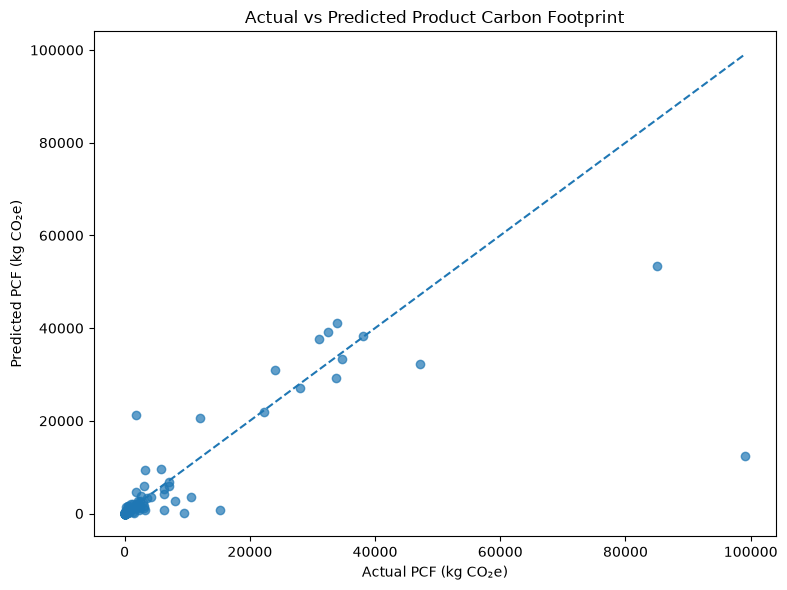

In [47]:
# ============================================================
# 40.3 ACTUAL VS PREDICTED
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    final_predictions_df["Actual_PCF"],
    final_predictions_df["Predicted_PCF"],
    alpha=0.7
)

# Perfect prediction line
min_value = min(
    final_predictions_df["Actual_PCF"].min(),
    final_predictions_df["Predicted_PCF"].min()
)

max_value = max(
    final_predictions_df["Actual_PCF"].max(),
    final_predictions_df["Predicted_PCF"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual PCF (kg CO₂e)")
plt.ylabel("Predicted PCF (kg CO₂e)")
plt.title("Actual vs Predicted Product Carbon Footprint")

plt.tight_layout()
plt.show()

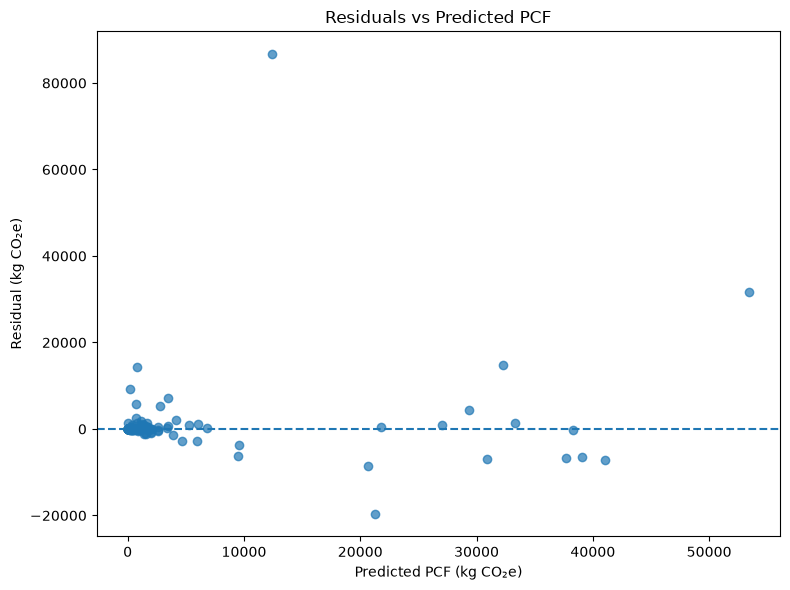

In [48]:
# ============================================================
# 40.4 RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    final_predictions_df["Predicted_PCF"],
    final_predictions_df["Residual"],
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted PCF (kg CO₂e)")
plt.ylabel("Residual (kg CO₂e)")
plt.title("Residuals vs Predicted PCF")

plt.tight_layout()
plt.show()

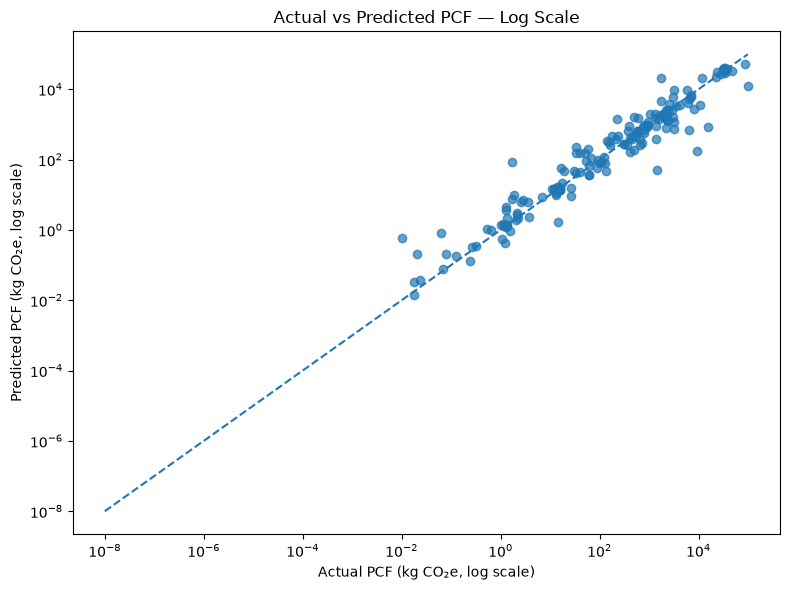

In [49]:
# ============================================================
# 40.5 LOG-SCALE ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    final_predictions_df["Actual_PCF"],
    final_predictions_df["Predicted_PCF"],
    alpha=0.7
)

# Perfect prediction line
positive_actual = (
    final_predictions_df["Actual_PCF"]
    .clip(lower=1e-8)
)

positive_predicted = (
    final_predictions_df["Predicted_PCF"]
    .clip(lower=1e-8)
)

min_value = min(
    positive_actual.min(),
    positive_predicted.min()
)

max_value = max(
    positive_actual.max(),
    positive_predicted.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Actual PCF (kg CO₂e, log scale)")
plt.ylabel("Predicted PCF (kg CO₂e, log scale)")
plt.title("Actual vs Predicted PCF — Log Scale")

plt.tight_layout()
plt.show()

In [50]:
# ============================================================
# 40.6 LARGEST PREDICTION ERRORS
# ============================================================

largest_errors = (
    final_predictions_df
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(15)
)

print("=" * 70)
print("TOP 15 LARGEST PREDICTION ERRORS")
print("=" * 70)

display(
    largest_errors
)

TOP 15 LARGEST PREDICTION ERRORS


,Actual_PCF,Predicted_PCF,Residual,Absolute_Error,Absolute_Percentage_Error
138,99075.0,12437.545898,86637.454102,86637.454102,87.446333
33,85000.0,53423.386719,31576.613281,31576.613281,37.148957
89,1750.0,21304.216797,-19554.216797,19554.216797,1117.383817
105,47200.0,32317.656250,14882.343750,14882.343750,31.530389
161,15196.6,816.947021,14379.652979,14379.652979,94.624146
80,9438.0,179.193146,9258.806854,9258.806854,98.101365
13,12000.0,20627.878906,-8627.878906,8627.878906,71.898991
120,10607.0,3498.237061,7108.762939,7108.762939,67.019543
163,34000.0,41067.289062,-7067.289062,7067.289062,20.786144
141,24000.0,30898.675781,-6898.675781,6898.675781,28.744482


In [51]:
# ============================================================
# 40.7 TEST TARGET DISTRIBUTION BY PCF RANGE
# ============================================================

test_error_bins = pd.cut(
    final_predictions_df["Actual_PCF"],
    bins=[
        -np.inf,
        100,
        1000,
        10000,
        50000,
        np.inf
    ],
    labels=[
        "< 100",
        "100–1,000",
        "1,000–10,000",
        "10,000–50,000",
        "> 50,000"
    ]
)

test_range_summary = (
    final_predictions_df
    .assign(PCF_Range=test_error_bins)
    .groupby("PCF_Range", observed=False)
    .agg(
        Count=("Actual_PCF", "size"),
        Mean_Actual=("Actual_PCF", "mean"),
        Mean_Absolute_Error=("Absolute_Error", "mean")
    )
    .reset_index()
)

print("=" * 70)
print("TEST PCF RANGE ERROR ANALYSIS")
print("=" * 70)

display(test_range_summary)

TEST PCF RANGE ERROR ANALYSIS


,PCF_Range,Count,Mean_Actual,Mean_Absolute_Error
0,< 100,81,14.218857,13.943865
1,"100–1,000",39,466.698974,214.835732
2,"1,000–10,000",39,3237.136410,2041.837532
3,"10,000–50,000",13,27931.507692,6122.261110
4,"> 50,000",2,92037.500000,59107.033691


### Final Reported Metrics


In [52]:
final_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [test_mae, test_rmse, test_r2]
})
display(final_results)


,Metric,Value
0,MAE,1649.098691
1,RMSE,7542.174649
2,R2,0.625097
